In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env.py
%run run.py connect

2025-07-18 15:19:02,873::INFO::settings.py::Setting loglevel to INFO
2025-07-18 15:19:02,874::INFO::settings.py::Setting stores to {}
2025-07-18 15:19:02,875::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-07-18 15:19:02,876::INFO::settings.py::Setting database.misc.create_tables to True
2025-07-18 15:19:02,878::INFO::settings.py::Setting enable_python_native_blobs to True
2025-07-18 15:19:02,879::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-07-18 15:19:02,880::INFO::settings.py::Setting database.user to celia
2025-07-18 15:19:02,881::INFO::settings.py::Setting database.password to celia
2025-07-18 15:19:02,936::INFO::connection.py::Connected celia@128.178.51.167:3309
2025-07-18 15:19:02,949::INFO::table.py::could not log event in table ~log


Connecting celia@128.178.51.167:3309


2025-07-18 15:19:03,359::INFO::table.py::could not log event in table ~log
2025-07-18 15:19:03,359::INFO::table.py::could not log event in table ~log
2025-07-18 15:19:03,376::INFO::table.py::could not log event in table ~log
2025-07-18 15:19:03,376::INFO::table.py::could not log event in table ~log
2025-07-18 15:19:03,402::INFO::table.py::could not log event in table ~log
2025-07-18 15:19:03,402::INFO::table.py::could not log event in table ~log
2025-07-18 15:19:03,426::INFO::table.py::could not log event in table ~log
2025-07-18 15:19:03,426::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
from vr4mice.schema.vr4mice import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema.interpolated_trajectories import (
    InterpolatedTrials,
    MeanXYTrajectory,
    MeanVelocities,
    YBinnedXYTrajectory,
)
from vr4mice.schema.session_metrics import TrialMetrics, SessionMetrics
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
import warnings

warnings.filterwarnings("ignore")


style()

2025-07-18 15:19:03,517::INFO::table.py::could not log event in table ~log
2025-07-18 15:19:03,517::INFO::table.py::could not log event in table ~log
2025-07-18 15:19:03,528::INFO::table.py::could not log event in table ~log
2025-07-18 15:19:03,528::INFO::table.py::could not log event in table ~log


In [5]:
from vr4mice.schema.vr4mice import State

In [6]:
from vr4mice.analysis.latency_testing import (
   detect_signal_polarity,
   filter_pulsed_signal,
   get_signals)

import cv2
import numpy as np

# From data examples (not on DJ)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Pre-process the photodiode signal

In [8]:
def binarise_signal(data, threshold=0.2):
    """
    Binarise a signal based on a threshold.
    """
    photodiode_read = data["photodiode_read"]
    photodiode_time = data["photodiode_time"] - data["start_time"]

    min_start = np.mean(photodiode_read[(photodiode_time > 1) & (photodiode_time < 3)])

    # remove first point as this corresponds to the thread starting
    if len(photodiode_time) != len(photodiode_read):
        photodiode_read = photodiode_read[1:]

    # Cut the 1s start delay to remove the initial noise
    # photodiode_read = photodiode_read[photodiode_time > 1]
    # photodiode_time = photodiode_time[photodiode_time > 1]

    flip_photodiode_signal = detect_signal_polarity(photodiode_read)
    filtered_photodiode_read = (
        filter_pulsed_signal(
            photodiode_read, int(1 // np.mean(np.diff(photodiode_time))), cutoff_freq=50
        )
        * flip_photodiode_signal
    )

    # Calculate the mean value prior to signal coming in to scale the signal and scale the trace
    filtered_photodiode_scaled = (filtered_photodiode_read - min_start) / (
        np.max(filtered_photodiode_read) - min_start
    )

    photodiode_signal_scaled = (photodiode_read - min_start) / (
        np.max(photodiode_read) - min_start
    )

    # binarise the signal
    photodiode_read = filtered_photodiode_scaled > threshold

    return pd.DataFrame(
        {
            "time_stamp": photodiode_time,
            "photodiode_read": photodiode_read,
            "photodiode_raw_scaled": photodiode_signal_scaled,
            "filtered_photodiode_scaled": filtered_photodiode_scaled,
            "threshold": threshold,
        }
    )

In [9]:
proc_filepath = (
    "/app/vr4mice/videos/full_videos_2/Imagingsource_CeliaTest_2025-07-18_3_PROC"
)
photodiode_data = np.load(proc_filepath, allow_pickle=True)

In [10]:
data = {
    "start_time": photodiode_data["start_time"],
    "photodiode_time": photodiode_data["photodiode_time"],
    "photodiode_read": photodiode_data["photodiode_read"],
    "generated_frame_time": photodiode_data["frame_time"],
    "generated_send_time": photodiode_data["time_stamp"],
    "generated_signal": photodiode_data["signal"],
}

data.keys()

photodiode = binarise_signal(data, threshold=0.2)

not flipping signal


In [11]:
photodiode = get_signals(data)

delay:  15.195821285247803
not flipping signal


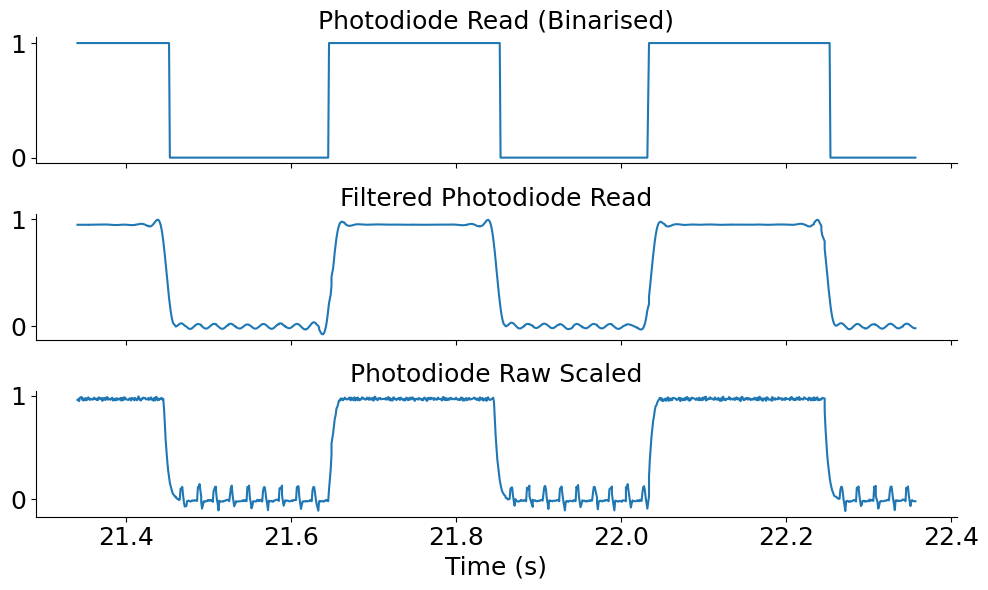

In [12]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

ax[0].plot(photodiode["time_stamp"][20000:21000],
           photodiode["photodiode_read"][20000:21000])
ax[0].set_title("Photodiode Read (Binarised)")

ax[1].plot(
    photodiode["time_stamp"][20000:21000],
    photodiode["filtered_photodiode_scaled"][20000:21000],
)
ax[1].set_title("Filtered Photodiode Read") 

ax[2].plot(photodiode["time_stamp"][20000:21000],
    photodiode["photodiode_raw_scaled"][20000:21000]
)
ax[2].set_title("Photodiode Raw Scaled")

plt.xlabel("Time (s)")
plt.tight_layout()

In [13]:
photodiode.to_pickle("photodiode.pkl")

## Process the video to extract sync signal

In [14]:
def extract_sync_signal_from_video(video_path, progress_interval=10000):
    """
    Extract sync signal from a video and return a DataFrame with frame ID, timestamp, and signal.

    Args:
        video_path (str): Path to the sync ROI video file
        progress_interval (int): Print progress every N frames (default: 10000)

    Returns:
        tuple: (df, video_fps, total_frames)
            - df: pandas DataFrame with columns [frame, timestamp, signal]
            - video_fps: frames per second of the video
            - total_frames: total number of frames processed
    """
    # Open video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video file: {video_path}")

    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"Processing video: {video_path}")
    print(f"Properties: {width}x{height}, {fps:.2f} fps, {total_frames} frames")

    data = []
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        raw_val = frame[0, 0].sum()
        signal = 0 if raw_val < 400 else 1
        timestamp = frame_count / fps

        data.append((frame_count, timestamp, signal))
        frame_count += 1

        if frame_count % progress_interval == 0:
            progress = (frame_count / total_frames) * 100
            print(f"Progress: {progress:.1f}% ({frame_count}/{total_frames} frames)")

    cap.release()

    df = pd.DataFrame(data, columns=["frame", "timestamp", "signal"])
    print(f"Extracted {len(df)} rows. Signal values: {df['signal'].min()} to {df['signal'].max()}")

    return df, fps, total_frames


In [15]:
video_sync_roi = "/app/vr4mice/videos/full_videos_2/2025-07-18 15-58-26_sync_roi.mkv"
sync_signal, fps, total_frames = extract_sync_signal_from_video(video_sync_roi)

Processing video: /app/vr4mice/videos/full_videos_2/2025-07-18 15-58-26_sync_roi.mkv
Properties: 20x20, 120.00 fps, 7990 frames


Extracted 7990 rows. Signal values: 0 to 1


In [16]:
sync_signal.head()

,frame,timestamp,signal
0,0,0.000000,0
1,1,0.008333,1
2,2,0.016667,1
3,3,0.025000,1
4,4,0.033333,1


In [17]:
sync_signal.to_pickle("sync_signal.pkl")

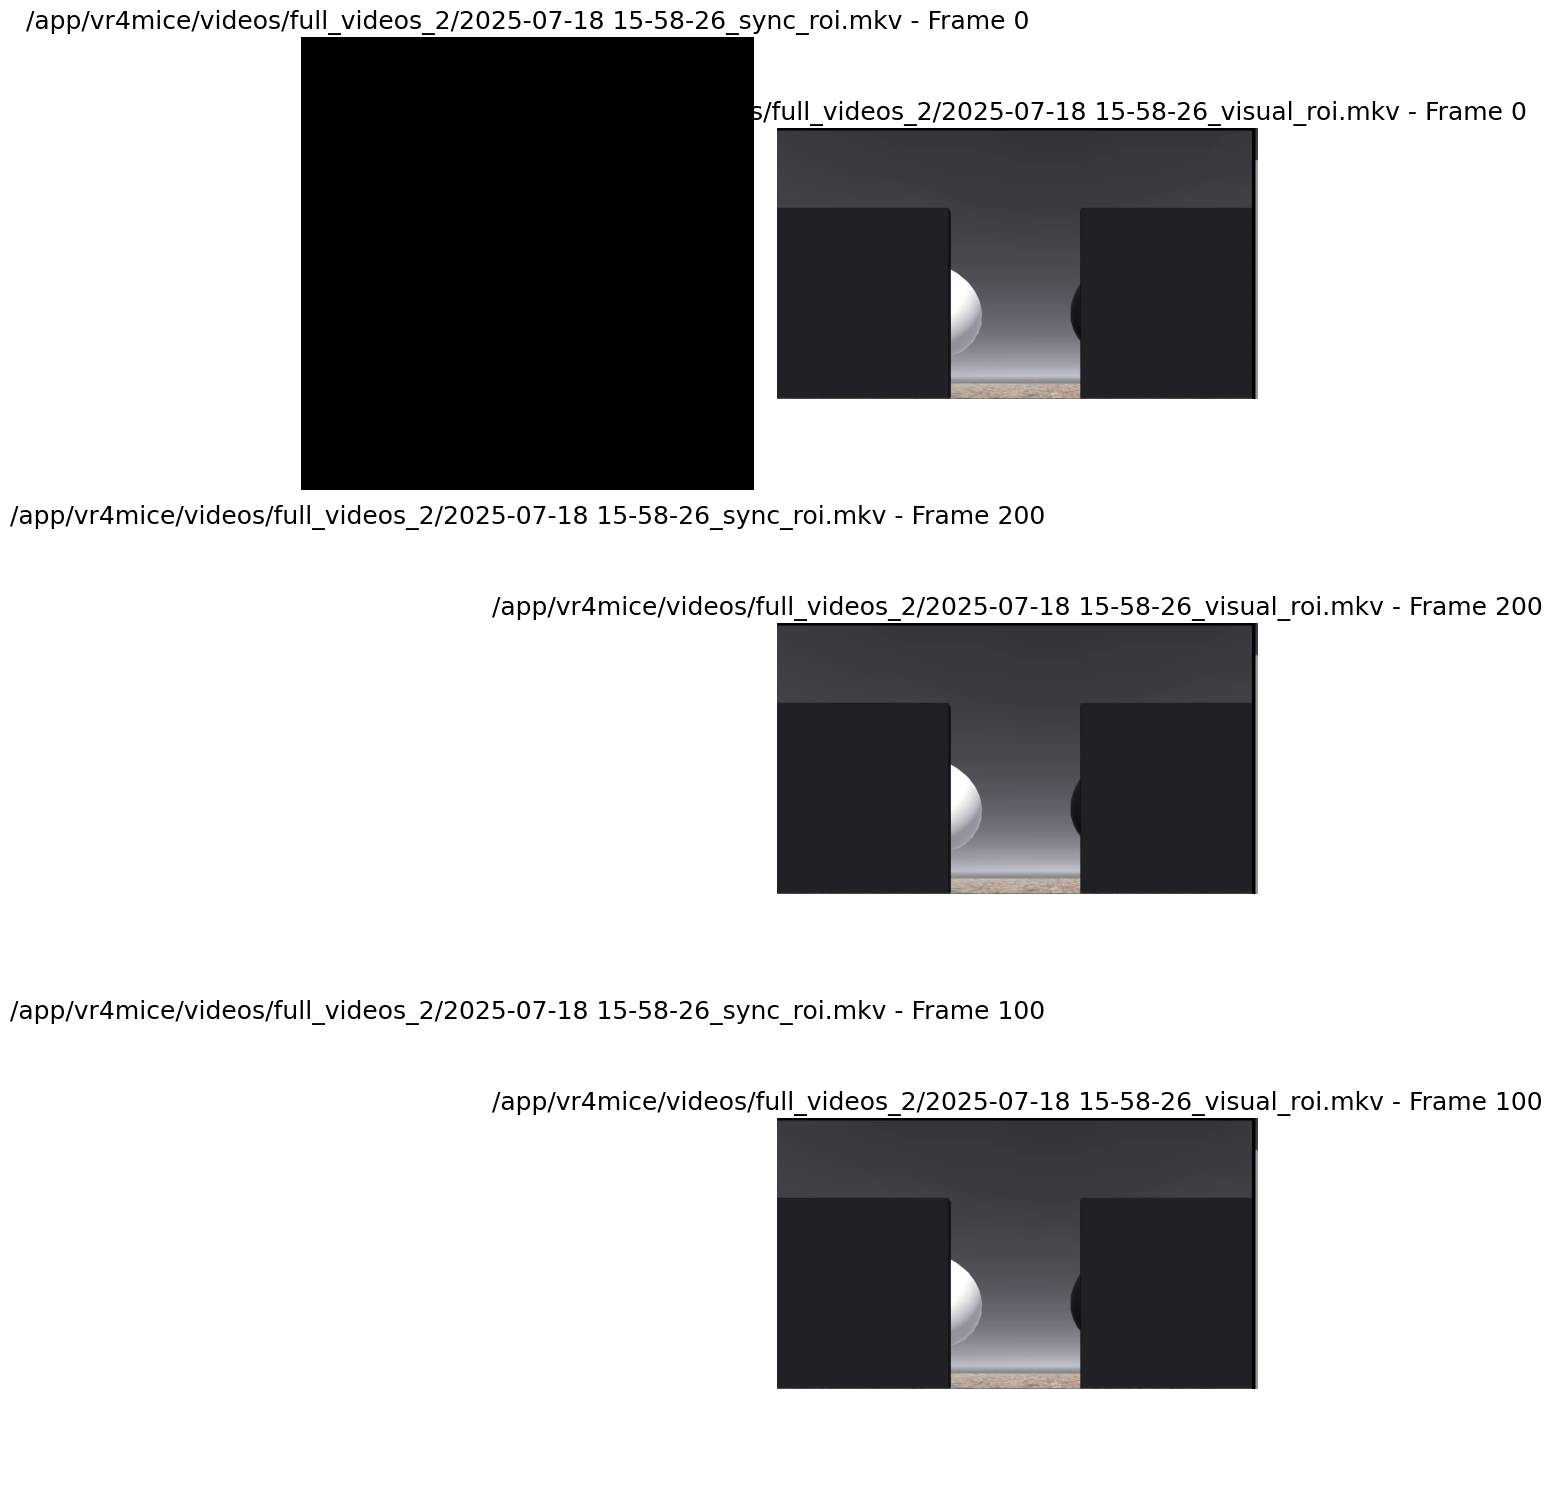

In [18]:
# Example frames
def extract_frames(video_path, frame_indices):
    cap = cv2.VideoCapture(video_path)
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
    cap.release()
    return frames

# Example usage
video1 = '/app/vr4mice/videos/full_videos_2/2025-07-18 15-58-26_sync_roi.mkv'
video2 = '/app/vr4mice/videos/full_videos_2/2025-07-18 15-58-26_visual_roi.mkv'
frame_indices = [0, 200, 100]  # replace with desired frame numbers

frames1 = extract_frames(video1, frame_indices)
frames2 = extract_frames(video2, frame_indices)

# Plot
fig, axs = plt.subplots(len(frame_indices), 2, figsize=(10, 5 * len(frame_indices)))
for i, (f1, f2) in enumerate(zip(frames1, frames2)):
    axs[i, 0].imshow(f1)
    axs[i, 0].set_title(f'{video1} - Frame {frame_indices[i]}')
    axs[i, 0].axis('off')
    axs[i, 1].imshow(f2)
    axs[i, 1].set_title(f'{video2} - Frame {frame_indices[i]}')
    axs[i, 1].axis('off')
plt.tight_layout()
plt.show()


Synchronize videos to photodiode signal is done in a separate file using the saved files.

## Synchronizing video/photodiode to DLC and game

In [19]:
resampled_video_frame_index = pd.read_csv("/app/vr4mice/videos/photodiode_timepoint_mapping.csv")
resampled_video_frame_index.head()

,photodiode_timepoint_index,video_frame_index,original_video_frame_index
0,0.0,114.0,114.0
1,1.0,114.0,114.0
2,2.0,115.0,115.0
3,3.0,115.0,115.0
4,4.0,115.0,115.0


In [20]:
len(resampled_video_frame_index), len(photodiode)

(168901, 168901)

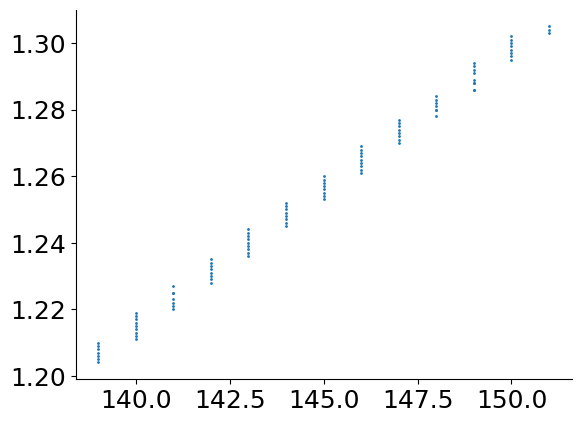

In [21]:
plt.scatter(resampled_video_frame_index["original_video_frame_index"][200:300], 
            photodiode["time_stamp"].iloc[resampled_video_frame_index["photodiode_timepoint_index"]][200:300], 
            s=1)

In [22]:
now_photodiode = pd.merge(photodiode, resampled_video_frame_index, left_index=True, right_index=True)
now_photodiode.head()

,time_stamp,photodiode_read,photodiode_raw_scaled,filtered_photodiode_scaled,threshold,send_time,frame_to_socket_time,signal_read,photodiode_timepoint_index,video_frame_index,original_video_frame_index
0,1.000998,False,-0.035894,-0.035560,0.2,8.697821,8.552821,0.0,0.0,114.0,114.0
1,1.002000,False,-0.041601,-0.033792,0.2,8.697821,8.552821,0.0,1.0,114.0,114.0
2,1.002998,False,-0.041601,-0.031443,0.2,8.697821,8.552821,0.0,2.0,115.0,115.0
3,1.003998,False,-0.047308,-0.028152,0.2,8.697821,8.552821,0.0,3.0,115.0,115.0
4,1.004997,False,-0.038747,-0.023706,0.2,8.697821,8.552821,0.0,4.0,115.0,115.0


In [53]:
now_photodiode.to_pickle("now_photodiode.pkl")

In [54]:
data["start_time"]

array(1.75284712e+09)

168901

In [49]:
game_data = pd.read_pickle("/app/vr4mice/videos/full_videos_2/CeliaTest_2025-07-18_1.pickle")
game_data.keys()

dict_keys(['start_time', 'episode', 'step', 'step_time', 'state', 'action', 'reward', 'terminal', 'session_label', 'dlc_read_time', 'dlc_x', 'dlc_y', 'dlc_heading', 'block_labels', 'slit_size', 'trial_slit_depth', 'r_report_box', 'l_report_box', 'start_box', 'cropped_image', 'unity_arena_size', 'camera_rotation', 'mouse_report_delay', 'velocity_threshold', 'start_box_delay', 'distractor', 'target_size', 'grey_screen_active', 'camera_type', 'target_selection', 'distractor_selection', 'occlusion_type', 'target_distance', 'target_rotation', 'reward_size', 'prob_obj_on_left', 'slit_size_param', 'block_length_param', 'rotate_camera_param', 'epoch_param', 'mouse_report_delay_param', 'prob_block_coherence', 'slit_depth_param', 'target_selection_param', 'distractor_selection_param', 'occlusion_type_param', 'target_spread_param', 'target_rotation_param', 'target_height_param', 'target_distance_param', 'trial_prob_object_left', 'trial_target_spread', 'trial_target_height'])

In [ ]:
step_time = game_data["step_time"]

KeyError: 'x_pos'

In [ ]:
dlc_read_time = ["dlc_read_time"]

In [51]:
len(dlc_read_time), len(step_time), len(game_data["dlc_x"]), len(game_data["reward"])

(10115, 12657, 10115, 12657)

In [45]:
len(data["generated_send_time"])

10100

In [40]:
dlc_read_time

array([1.75284713e+09, 1.75284713e+09, 1.75284713e+09, ...,
       1.75284729e+09, 1.75284729e+09, 1.75284729e+09])

In [35]:
now_photodiode["signal_read"]

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
168896    0.0
168897    0.0
168898    0.0
168899    0.0
168900    0.0
Name: signal_read, Length: 168901, dtype: float64